In [3]:
### imports...
import numpy as np
import matplotlib.pyplot as plt

In [28]:
### basic work for paper tables wrt dataset size
layer_res = [30, 30, 30, 30, 30, 30, 30, 30, 800, 800, 800, 800, 800, 800, 1000, 70, 70, 1000]
pyr_x = np.array([34, 34, 34, 34, 34, 34, 34, 34, 2, 2, 2, 2, 2, 2, 1, 15, 15, 1])
cube_x = np.array([34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 15, 15, 1])
old_adj_x = np.array([24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 15, 15, 1])
adj_x = np.array([25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 15, 15, 1])
y_sum = np.sum(np.array([15, 15, 1]) ** 2)

In [30]:
params_pyr = np.sum(pyr_x ** 2)
params_cube = np.sum(cube_x ** 2)
params_adj = np.sum(adj_x ** 2)
params_old = np.sum(old_adj_x ** 2)

In [63]:
print(params_pyr)
print(params_cube)
print(params_adj)
print("***")
print(params_pyr - y_sum)
print(params_cube - y_sum)
print(params_adj - y_sum)
print("***")
print(1 - (params_pyr/params_cube))

9724
17791
9826
***
9273
17340
9375
***
0.4534315103142038


In [32]:
### overhead and storage cost graph
gb_pyr = 3.86
gb_cube = 7.06
gb_adj = (params_adj / params_old) * 3.61

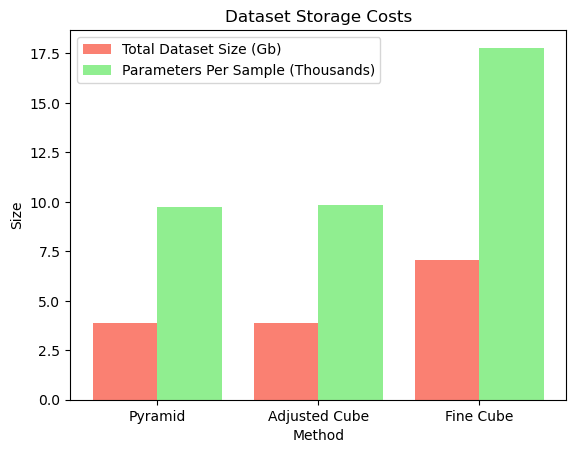

In [62]:
names = ["Pyramid", "Adjusted Cube", "Fine Cube"]
index = np.array([1, 2, 3])
fig, ax = plt.subplots()
disk = ax.bar(index-0.5, [gb_pyr, gb_adj, gb_cube], 0.4, color="salmon")
disk = ax.bar(index-0.1, [params_pyr/1000, params_adj/1000, params_cube/1000], 0.4, color="lightgreen")

ax.set_xticks(index-0.3, names)
ax.set_title("Dataset Storage Costs")
ax.legend(loc='upper left', labels=["Total Dataset Size (Gb)", "Parameters Per Sample (Thousands)"])
ax.set_ylabel('Size')
ax.set_xlabel('Method')

plt.savefig("data_cost_figs/storage_cost.png")

In [ ]:
### work on graph for overhead time cost

In [74]:
### ok -- now compile results for model performance table...
import pickle

models_locs = [["../models/trained/c2_early_pyramid", "cascade_early_1"],
               ["../models/trained/c2_early_cube", "cascade_early_1"],
               ["../models/trained/c2_early_adjust", "cascade_early_1"]]




In [75]:
### load metrics pickles
models_metrics = []
for i in range(len(models_locs)):
    print(models_locs[i][0] + "/metrics.txt")
    with open(models_locs[i][0] + "/metrics.txt", "rb") as metrics_log:
        models_metrics.append(pickle.load(metrics_log))

../models/trained/c2_early_pyramid/metrics.txt
../models/trained/c2_early_cube/metrics.txt
../models/trained/c2_early_adjust/metrics.txt


In [87]:
### organization: [metric_type, ylayer, fold]
y_layer_names = ["wue", "esi", "agb"]
print(models_metrics[0]["total_time"])
for i in range(len(models_metrics)):
    for j in range(3):
        print(models_locs[i][0], "--", y_layer_names[j] + "_mse", np.mean(models_metrics[i]["mse_single"][j][0]))
    print(models_locs[i][0], "--", y_layer_names[j] + "_time", models_metrics[i]["total_time"])

149.165179
../models/trained/c2_early_pyramid -- wue_mse 0.0014740794553201
../models/trained/c2_early_pyramid -- esi_mse 0.011404735148301095
../models/trained/c2_early_pyramid -- agb_mse 0.1061678263918955


TypeError: unsupported operand type(s) for /: 'dict' and 'int'